# Google Play Store App Analysis

In [1]:
pip install google-play-scraper

Note: you may need to restart the kernel to use updated packages.


In [4]:
import socket
import time
import pandas as pd

WEB SCRAPPING

In [3]:

def step1_check_connection():
    print("STEP 1: Checking internet connection...")
    try:
        socket.gethostbyname("play.google.com")
        print(" DNS resolved play.google.com successfully. Internet is OK.\n")
        return True
    except socket.gaierror as e:
        print(f" Could not resolve play.google.com: {e}")
        print("  -> Fix your network/DNS/VPN before continuing.")
        print("     Try: nslookup play.google.com  (in a terminal)")
        print("     Try switching off VPN, or using mobile hotspot to test.\n")
        return False
 
 
# ---------------------------------------------------------------------
# STEP 2: Import the scraper library (fails here if not installed)
# ---------------------------------------------------------------------
def step2_import_library():
    print("STEP 2: Importing google-play-scraper...")
    try:
        global gp_app, gp_search
        from google_play_scraper import app as gp_app
        from google_play_scraper import search as gp_search
        print(" Library imported.\n")
        return True
    except ImportError as e:
        print(f"Import failed: {e}")
        print("  -> Run: pip install google-play-scraper\n")
        return False
 
 
# ---------------------------------------------------------------------
# STEP 3: Test a single, known-good app fetch before doing anything bulk
# ---------------------------------------------------------------------
def step3_test_single_fetch(country="in", lang="en"):
    print("STEP 3: Testing a single app fetch (com.whatsapp)...")
    try:
        details = gp_app("com.whatsapp", lang=lang, country=country)
        print(f" Success. Got data for: {details.get('title')}")
        print(f" Rating: {details.get('score')}, Installs: {details.get('installs')}\n")
        return True
    except Exception as e:
        print(f" Fetch failed: {e}\n")
        return False
 
 
# ---------------------------------------------------------------------
# STEP 4: Search for apps by keyword to build a list of app IDs
# ---------------------------------------------------------------------
def step4_search_apps(search_terms, n_per_term=20, country="in", lang="en", delay=0.5):
    print("STEP 4: Searching for apps by keyword...")
    app_ids = set()
    for term in search_terms:
        try:
            results = gp_search(term, lang=lang, country=country, n_hits=n_per_term)
            found = [r["appId"] for r in results]
            app_ids.update(found)
            print(f" '{term}': found {len(found)} apps")
        except Exception as e:
            print(f"  '{term}' failed: {e}")
        time.sleep(delay)
    print(f"  Total unique app IDs collected: {len(app_ids)}\n")
    return list(app_ids)
 
 
# ---------------------------------------------------------------------
# STEP 5: Fetch full details for every app ID and map to notebook schema
# ---------------------------------------------------------------------
def step5_fetch_all_details(app_ids, country="in", lang="en", delay=0.5):
    print(f"STEP 5: Fetching details for {len(app_ids)} apps...")
    rows = []
    for i, app_id in enumerate(app_ids, 1):
        try:
            d = gp_app(app_id, lang=lang, country=country)
            rows.append({
                "App": d.get("title"),
                "Category": d.get("genreId"),
                "Rating": d.get("score"),
                "Reviews": d.get("ratings"),
                "Size": d.get("size") or "Varies with device",
                "Installs": d.get("installs"),
                "Type": "Free" if d.get("free") else "Paid",
                "Price": d.get("price", 0.0),
                "Content Rating": d.get("contentRating"),
                "Genres": d.get("genre"),
                "Last Updated": d.get("updated"),
                "Current Ver": d.get("version"),
                "Android Ver": d.get("androidVersion"),
            })
        except Exception as e:
            print(f" Skipping {app_id}: {e}")
        if i % 10 == 0:
            print(f"  ...{i}/{len(app_ids)} done")
        time.sleep(delay)
    print(f" Collected {len(rows)} app records.\n")
    return rows
 
 
# ---------------------------------------------------------------------
# STEP 6: Build the DataFrame, clean the date column, save to CSV
# ---------------------------------------------------------------------
def step6_save_csv(rows, output_csv="googleplaystore_scraped.csv"):
    print("STEP 6: Saving to CSV...")
    df = pd.DataFrame(rows)
    if "Last Updated" in df.columns:
        df["Last Updated"] = pd.to_datetime(
            df["Last Updated"], unit="s", errors="coerce"
        ).dt.strftime("%B %-d, %Y")
    df.to_csv(output_csv, index=False)
    print(f" Saved {len(df)} rows to {output_csv}\n")
    return df
 
 
# ---------------------------------------------------------------------
# RUN ALL STEPS IN ORDER
# ---------------------------------------------------------------------
if __name__ == "__main__":
    APP_IDS = [
        "com.whatsapp",
        "com.instagram.android",
        "com.spotify.music",
        "com.netflix.mediaclient",
        "com.google.android.apps.maps",
    ]
    # Broad keyword coverage across Play Store categories — each search call
    # returns roughly 20-30 unique apps, so more/varied terms = more data.
    SEARCH_TERMS = [
        # Art & Design
        "photo editor", "coloring book", "drawing app", "graphic design",
        # Auto & Vehicles
        "car parts", "driving test",
        # Beauty
        "makeup app", "skincare tracker",
        # Books & Reference
        "ebook reader", "dictionary app",
        # Business
        "invoice maker", "crm app",
        # Communication
        "messenger app", "video call app",
        # Dating
        "dating app",
        # Education
        "learning app", "language learning", "quiz app",
        # Entertainment
        "streaming app", "meme app",
        # Finance
        "budget tracker", "banking app", "stock trading app",
        # Food & Drink
        "recipe app", "food delivery",
        # Games
        "puzzle game", "racing game", "arcade game", "strategy game",
        # Health & Fitness
        "workout app", "meditation app", "step counter",
        # House & Home
        "home design app",
        # Libraries & Demo
        "sdk demo",
        # Lifestyle
        "horoscope app",
        # Maps & Navigation
        "gps navigation", "offline maps",
        # Medical
        "medicine reminder",
        # Music & Audio
        "music player", "podcast app",
        # News & Magazines
        "news app",
        # Parenting
        "baby tracker",
        # Personalization
        "launcher", "wallpaper app", "keyboard app",
        # Photography
        "camera app", "photo collage",
        # Productivity
        "note taking app", "to do list", "pdf reader",
        # Shopping
        "shopping app",
        # Social
        "social media app",
        # Sports
        "sports scores app",
        # Tools
        "flashlight app", "file manager", "vpn app",
        # Travel & Local
        "travel booking", "hotel booking",
        # Video Players & Editors
        "video editor", "video player",
        # Weather
        "weather app",
    ]
 
    if not step1_check_connection():
        raise SystemExit("Fix your internet/DNS connection, then rerun.")
 
    if not step2_import_library():
        raise SystemExit("Install the library, then rerun.")
 
    if not step3_test_single_fetch():
        raise SystemExit("Single test fetch failed — network is reachable but "
                          "Play Store requests are being blocked. Check firewall/proxy.")
 
    searched_ids = step4_search_apps(SEARCH_TERMS, n_per_term=30)
    all_ids = list(set(APP_IDS) | set(searched_ids))
 
    rows = step5_fetch_all_details(all_ids)
    df = step6_save_csv(rows)
 
    print("DONE. Preview:")
    print(df.head())
 

STEP 1: Checking internet connection...
 DNS resolved play.google.com successfully. Internet is OK.

STEP 2: Importing google-play-scraper...
 Library imported.

STEP 3: Testing a single app fetch (com.whatsapp)...
 Success. Got data for: WhatsApp Messenger
 Rating: 4.4415708, Installs: 10,000,000,000+

STEP 4: Searching for apps by keyword...
 'photo editor': found 30 apps
 'coloring book': found 30 apps
 'drawing app': found 21 apps
 'graphic design': found 30 apps
 'car parts': found 30 apps
 'driving test': found 30 apps
 'makeup app': found 30 apps
 'skincare tracker': found 30 apps
 'ebook reader': found 30 apps
 'dictionary app': found 30 apps
 'invoice maker': found 30 apps
 'crm app': found 30 apps
 'messenger app': found 19 apps
 'video call app': found 30 apps
 'dating app': found 24 apps
 'learning app': found 30 apps
 'language learning': found 30 apps
 'quiz app': found 14 apps
 'streaming app': found 30 apps
 'meme app': found 30 apps
 'budget tracker': found 30 apps
 'b

 DATA LOADING

In [5]:
df = pd.read_csv(r"googleplaystore_scraped.csv")

DATA UNDERSTANDING AND INITIAL INSPECTION

In [12]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,AstroLokal: Talk to Astrologer,LIFESTYLE,4.455645,9826.0,Varies with device,"5,000,000+",Free,0.0,Rated for 3+,Lifestyle,2026-08-24 11:07:29,0.0.55,NaN
1,Focus To-Do: Pomodoro & Tasks,PRODUCTIVITY,4.473022,284768.0,Varies with device,"10,000,000+",Free,0.0,Rated for 3+,Productivity,2026-08-28 03:18:15,Varies with device,NaN
2,Subway Surfers,GAME_ARCADE,4.414331,41569389.0,Varies with device,"1,000,000,000+",Free,0.0,Rated for 7+,Arcade,2026-09-02 12:35:22,3.68.4,NaN
3,Medication Reminder & Tracker,MEDICAL,4.420000,6702.0,Varies with device,"100,000+",Free,0.0,Rated for 3+,Medical,2026-04-21 21:53:43,10.9,NaN
4,ELSA Speak: English Learning,EDUCATION,4.231390,1000549.0,Varies with device,"10,000,000+",Free,0.0,Rated for 3+,Education,2026-08-17 04:34:48,9.1.8,NaN


In [13]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1545,Fruit Ninja®,GAME_ARCADE,4.061114,5337052.0,Varies with device,"500,000,000+",Free,0.0,Rated for 3+,Arcade,2026-08-21 07:27:00,3.97.6,NaN
1546,Finger Paint Coloring Book,EDUCATION,3.480000,2387.0,Varies with device,"5,000,000+",Free,0.0,Rated for 3+,Education,2025-12-05 15:33:20,3.2,NaN
1547,Beach Buggy Racing 2,GAME_RACING,4.362342,916055.0,Varies with device,"100,000,000+",Free,0.0,Rated for 3+,Racing,2026-07-31 23:44:11,2026.07.31,NaN
1548,Photo Lab Picture Editor & Art,PHOTOGRAPHY,4.050466,6576014.0,Varies with device,"100,000,000+",Free,0.0,Rated for 12+,Photography,2026-09-01 17:24:39,3.13.117,NaN
1549,Sololearn: Learn to code,EDUCATION,4.464923,748786.0,Varies with device,"10,000,000+",Free,0.0,Rated for 12+,Education,2026-08-24 12:50:44,4.130.11,NaN


In [14]:
df.head(20)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,AstroLokal: Talk to Astrologer,LIFESTYLE,4.455645,9826.0,Varies with device,"5,000,000+",Free,0.0,Rated for 3+,Lifestyle,2026-08-24 11:07:29,0.0.55,NaN
1,Focus To-Do: Pomodoro & Tasks,PRODUCTIVITY,4.473022,284768.0,Varies with device,"10,000,000+",Free,0.0,Rated for 3+,Productivity,2026-08-28 03:18:15,Varies with device,NaN
2,Subway Surfers,GAME_ARCADE,4.414331,41569389.0,Varies with device,"1,000,000,000+",Free,0.0,Rated for 7+,Arcade,2026-09-02 12:35:22,3.68.4,NaN
3,Medication Reminder & Tracker,MEDICAL,4.420000,6702.0,Varies with device,"100,000+",Free,0.0,Rated for 3+,Medical,2026-04-21 21:53:43,10.9,NaN
4,ELSA Speak: English Learning,EDUCATION,4.231390,1000549.0,Varies with device,"10,000,000+",Free,0.0,Rated for 3+,Education,2026-08-17 04:34:48,9.1.8,NaN
5,VPN Lumos: Fast VPN,TOOLS,3.762266,799567.0,Varies with device,"10,000,000+",Free,0.0,Rated for 3+,Tools,NaN,Varies with device,NaN
6,ARtie Lab: AR Drawing & Sketch,ART_AND_DESIGN,4.147059,53541.0,Varies with device,"1,000,000+",Free,0.0,Rated for 3+,Art & Design,2026-07-30 19:35:57,1.0.4,NaN
7,Zodiac & Horoscope: CosmicVibe,LIFESTYLE,4.250000,8757.0,Varies with device,"100,000+",Free,0.0,Rated for 3+,Lifestyle,2026-08-31 22:03:42,1.7.1,NaN
8,Spotify for Creators,MUSIC_AND_AUDIO,3.420454,84711.0,Varies with device,"10,000,000+",Free,0.0,Rated for 12+,Music & Audio,2026-08-31 13:38:14,7.114.2.1,NaN
9,MEAM - The Meme Maker Pro,ENTERTAINMENT,4.296296,166.0,Varies with device,"10,000+",Paid,220.0,Rated for 16+,Entertainment,2026-04-25 16:03:52,2.2.2,NaN


In [15]:
df.describe()

,Rating,Reviews,Price,Android Ver
count,1440.000000,1.440000e+03,1547.000000,0.0
mean,4.293195,2.212456e+06,24.956031,NaN
std,0.417548,1.174690e+07,330.840237,NaN
min,1.722054,7.000000e+00,0.000000,NaN
25%,4.094092,1.704075e+04,0.000000,NaN
50%,4.379073,1.710420e+05,0.000000,NaN
75%,4.571882,1.001059e+06,0.000000,NaN
max,5.000000,2.426567e+08,10000.000000,NaN


In [16]:
df.shape

(1550, 13)

In [17]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews           float64
Size               object
Installs           object
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver       float64
dtype: object

DATA CLEANING AND HANDLING NULL VALUES

In [18]:
df.isnull().sum()

App                  0
Category             0
Rating             110
Reviews            110
Size                 0
Installs             3
Type                 0
Price                3
Content Rating       0
Genres               0
Last Updated       162
Current Ver          0
Android Ver       1550
dtype: int64

In [19]:
median_rating = df["Rating"].median()
df["Rating"] = df["Rating"].fillna(median_rating)
print("Median Rating:", median_rating)


Median Rating: 4.37907315


In [20]:
print("Missing Ratings:", df["Rating"].isnull().sum())

Missing Ratings: 0


In [21]:
df["Rating"].describe()

count    1550.000000
mean        4.299290
std         0.403053
min         1.722054
25%         4.114875
50%         4.379073
75%         4.560000
max         5.000000
Name: Rating, dtype: float64

In [22]:
median_reviews = df["Reviews"].median()
df["Reviews"] = df["Reviews"].fillna(median_reviews)
print("Median Reviews:", median_reviews)
print("Missing Reviews:", df["Reviews"].isnull().sum()

Median Reviews: 171042.0
Missing Reviews: 0


In [25]:
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")
print("Missing Installs:", df["Installs"].isnull().sum())
print(df["Installs"].head())

Missing Installs: 3
0    5.000000e+06
1    1.000000e+07
2    1.000000e+09
3    1.000000e+05
4    1.000000e+07
Name: Installs, dtype: float64


In [26]:
median_installs = df["Installs"].median()
df["Installs"] = df["Installs"].fillna(median_installs)
print("Median Installs:", median_installs)
print("Missing Installs:", df["Installs"].isnull().sum())

Median Installs: 10000000.0
Missing Installs: 0


In [27]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
print("Missing Price:", df["Price"].isnull().sum())

Missing Price: 3


In [28]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"],errors="coerce")
print("Data Type:", df["Last Updated"].dtype)
print("Missing Dates:", df["Last Updated"].isnull().sum())

Data Type: datetime64[ns]
Missing Dates: 162


In [29]:
df = df.drop(columns=["Android Ver"])

In [30]:
df = df.drop(columns=["Size"])

In [31]:
df.isnull().sum()

App                 0
Category            0
Rating              0
Reviews             0
Installs            0
Type                0
Price               3
Content Rating      0
Genres              0
Last Updated      162
Current Ver         0
dtype: int64

In [34]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (1550, 11)

Columns:
['App', 'Category', 'Rating', 'Reviews', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver']

Missing values:
App                 0
Category            0
Rating              0
Reviews             0
Installs            0
Type                0
Price               3
Content Rating      0
Genres              0
Last Updated      162
Current Ver         0
dtype: int64

Duplicate rows: 0


In [36]:
df[df["App"].duplicated(keep=False)].sort_values("App")

,App,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver
1181,Alberta Driving Test Practice,EDUCATION,4.684210,1164.0,1.000000e+04,Free,0.0,Rated for 3+,Education,2026-06-06 19:27:21,24.0.5562
754,Alberta Driving Test Practice,BOOKS_AND_REFERENCE,4.720000,1992.0,5.000000e+04,Free,0.0,Rated for 3+,Books & Reference,2025-12-25 03:20:07,1.9.44
651,"Cookpad recipes, homemade food",FOOD_AND_DRINK,4.437500,346854.0,1.000000e+07,Free,0.0,Rated for 12+,Food & Drink,2026-08-31 04:19:29,26.36.0.1
766,"Cookpad recipes, homemade food",FOOD_AND_DRINK,3.588235,119591.0,1.000000e+07,Free,0.0,Rated for 3+,Food & Drink,2026-08-31 04:18:45,26.36.0.1
723,Demo App,EDUCATION,4.379073,171042.0,1.000000e+02,Free,0.0,Rated for 3+,Education,NaT,Varies with device
1423,Demo App,FOOD_AND_DRINK,4.463415,88.0,1.000000e+04,Free,0.0,Rated for 3+,Food & Drink,NaT,Varies with device
259,File Manager,TOOLS,4.579820,196867.0,5.000000e+06,Free,0.0,Rated for 3+,Tools,2026-08-26 10:17:01,1.5.5.7
820,File Manager,PRODUCTIVITY,4.545166,1700616.0,1.000000e+08,Free,0.0,Rated for 3+,Productivity,2026-08-06 07:42:12,Varies with device
598,File Manager,TOOLS,4.400152,4377675.0,1.000000e+09,Free,0.0,Rated for 12+,Tools,2024-05-13 06:43:13,V1-210601
895,Flashlight,TOOLS,3.940000,3310.0,5.000000e+05,Free,0.0,Rated for 3+,Tools,2026-07-08 09:57:46,4.3


In [38]:
df["Category"].value_counts()

Category
PRODUCTIVITY           96
TOOLS                  95
HEALTH_AND_FITNESS     90
FINANCE                87
EDUCATION              82
BUSINESS               71
PERSONALIZATION        61
PHOTOGRAPHY            61
BOOKS_AND_REFERENCE    56
FOOD_AND_DRINK         53
TRAVEL_AND_LOCAL       51
ENTERTAINMENT          48
VIDEO_PLAYERS          46
LIFESTYLE              46
ART_AND_DESIGN         38
MUSIC_AND_AUDIO        36
SHOPPING               35
SOCIAL                 34
COMMUNICATION          32
SPORTS                 32
MAPS_AND_NAVIGATION    32
NEWS_AND_MAGAZINES     31
BEAUTY                 31
WEATHER                30
GAME_RACING            25
GAME_STRATEGY          25
PARENTING              23
GAME_PUZZLE            23
MEDICAL                19
GAME_CASUAL            19
GAME_ARCADE            18
GAME_EDUCATIONAL       17
HOUSE_AND_HOME         16
AUTO_AND_VEHICLES      16
DATING                 15
GAME_BOARD             14
GAME_SIMULATION        11
GAME_ACTION            10
GAM

In [39]:
df["Type"].value_counts()

Type
Free    1519
Paid      31
Name: count, dtype: int64

In [40]:
import pandas as pd
df = pd.read_csv("googleplaystore_scraped.csv")
df["Price"] = (df["Price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False).str.strip())
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
print(df[["App", "Type", "Price"]].head(20))

                               App  Type  Price
0   AstroLokal: Talk to Astrologer  Free    0.0
1    Focus To-Do: Pomodoro & Tasks  Free    0.0
2                   Subway Surfers  Free    0.0
3    Medication Reminder & Tracker  Free    0.0
4     ELSA Speak: English Learning  Free    0.0
5              VPN Lumos: Fast VPN  Free    0.0
6   ARtie Lab: AR Drawing & Sketch  Free    0.0
7   Zodiac & Horoscope: CosmicVibe  Free    0.0
8             Spotify for Creators  Free    0.0
9        MEAM - The Meme Maker Pro  Paid  220.0
10                 Yoga | Down Dog  Free    0.0
11        PDF Chef: Tools & Reader  Free    0.0
12  HelloLeads CRM - Sales Tracker  Free    0.0
13        Yodha My Daily Horoscope  Free    0.0
14    Medisafe Pill & Med Reminder  Free    0.0
15  Horoscope in Kannada : Jathaka  Free    0.0
16    Car-Part.com Used Auto Parts  Free    0.0
17  TickTick:To Do List & Calendar  Free    0.0
18                      Telegram X  Free    0.0
19    Dosecast - Pill Reminder App  Free

In [41]:
paid_apps = df[df["Type"] == "Paid"][["App", "Type", "Price"]]
print(paid_apps.to_string(index=False))

                           App Type    Price
     MEAM - The Meme Maker Pro Paid   220.00
ReadEra Premium – ebook reader Paid  1190.00
        Video Player - OPlayer Paid   410.00
              Skincare Routine Paid   390.00
              Moon+ Reader Pro Paid  1300.00
City Maps 2Go Pro Offline Maps Paid  1350.00
      Dictionary - M-W Premium Paid   700.00
Money Manager & Budget Tracker Paid   130.00
Oh She Glows - Healthy Recipes Paid   280.00
    House Design Floor Plan 3D Paid      NaN
              Launcher OS™ Pro Paid   149.99
  Hanping Cantonese Dictionary Paid  1050.00
 Horoscope+: Ad-Free Astrology Paid   990.00
MemeNow Pro - Meme Generator & Paid   520.00
 AlpineQuest Off-Road Explorer Paid  1349.99
 Medication Tracker & Reminder Paid   110.00
            Meme Generator PRO Paid  3750.00
                    ibis Paint Paid     4.00
  Driving Theory Test 2026 Kit Paid   380.00
    Flikt - Flashlight & Torch Paid    55.00
  League of Legends: Wild Rift Paid      NaN
 German Di

EXPLORATORY DATA ANALYSIS (EDA)

In [42]:
import matplotlib.pyplot as plt


UNIVARIATE ANALYSIS

In [43]:
# App Distribution by Category

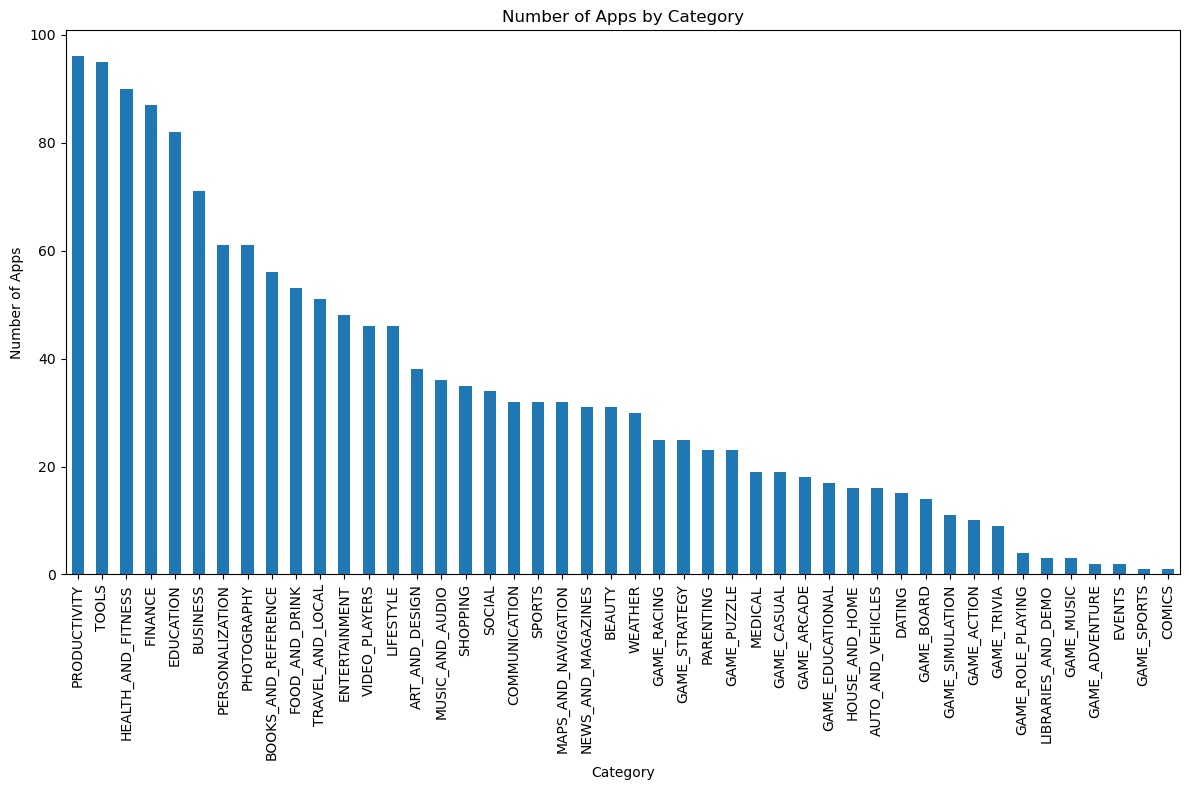

In [44]:
category_counts = df["Category"].value_counts()
plt.figure(figsize=(12, 8))
category_counts.plot(kind="bar")
plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [45]:
# Free vs Paid apps

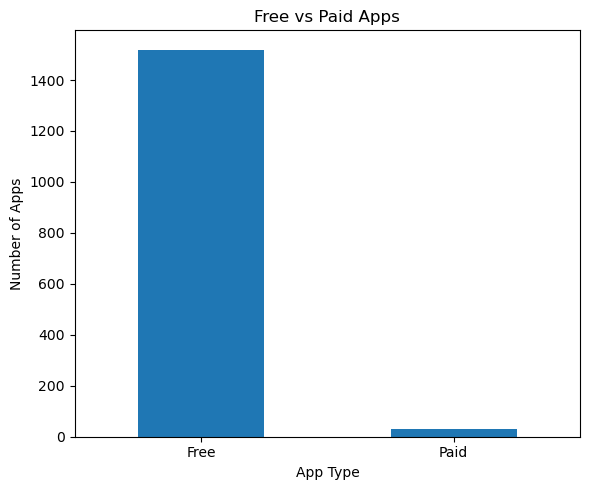

In [46]:
type_counts = df["Type"].value_counts()
plt.figure(figsize=(6, 5))
type_counts.plot(kind="bar")
plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
type_percentage = df["Type"].value_counts(normalize=True) * 100
print(type_percentage)

Type
Free    98.0
Paid     2.0
Name: proportion, dtype: float64


In [48]:
# Rating Distribution

In [49]:
df["Rating"].describe()

count    1440.000000
mean        4.293195
std         0.417548
min         1.722054
25%         4.094092
50%         4.379073
75%         4.571882
max         5.000000
Name: Rating, dtype: float64

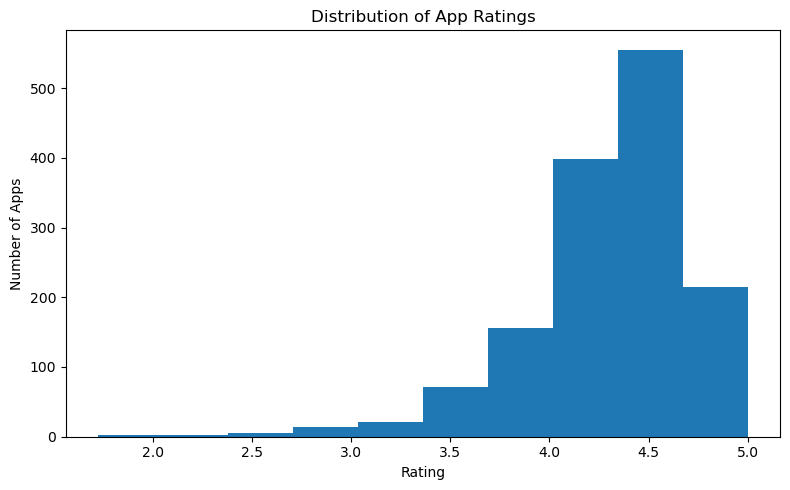

In [50]:
plt.figure(figsize=(8, 5))
plt.hist(df["Rating"], bins=10)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

In [51]:
# Installs Analysis

In [52]:
df["Installs"].describe()

count            1547
unique             22
top       10,000,000+
freq              350
Name: Installs, dtype: object

TypeError: 'value' must be an instance of str or bytes, not a float

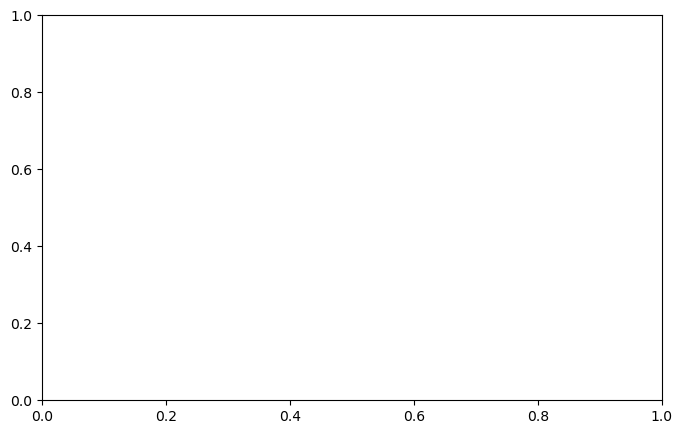

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(df["Installs"], bins=20)
plt.xscale("log")
plt.title("Distribution of App Installs (Log Scale)")
plt.xlabel("Number of Installs")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

In [ ]:
# Reviews Analysis

In [ ]:
df["Reviews"].describe()

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(df["Reviews"], bins=20)
plt.xscale("log")
plt.title("Distribution of App Reviews (Log Scale)")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

In [ ]:
# Price Analysis

In [ ]:
df[df["Price"] > 0]["Price"].describe()

In [ ]:
paid_prices = df[df["Price"] > 0]["Price"]
plt.figure(figsize=(8, 5))
plt.hist(paid_prices, bins=10)
plt.title("Distribution of Paid App Prices")
plt.xlabel("Price")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

BIVARIATE ANALYSIS

In [ ]:
# Installs vs Reviews

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Installs"], df["Reviews"], alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.title("Installs vs Reviews")
plt.xlabel("Number of Installs")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [56]:
df["Installs"] = (df["Installs"].astype(str).str.replace(",", "", regex=False).str.replace("+", "", regex=False))
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")
median_installs = df["Installs"].median()
df["Installs"] = df["Installs"].fillna(median_installs)
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
correlation = df["Installs"].corr(df["Reviews"])
print("Correlation between Installs and Reviews:", correlation)

Correlation between Installs and Reviews: 0.6053210230842142


In [57]:
# Rating vs Reviews

In [58]:
correlation_rating_reviews = df["Rating"].corr(df["Reviews"])
print("Correlation between Rating and Reviews:",correlation_rating_reviews)

Correlation between Rating and Reviews: 0.023884223739140415


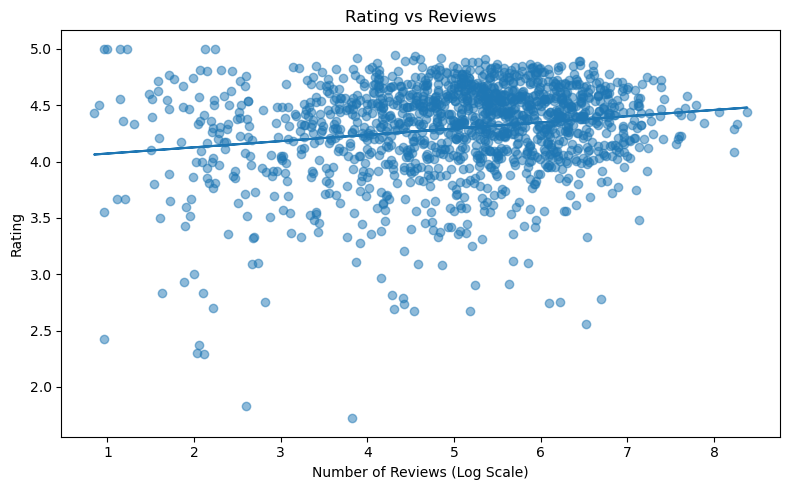

In [60]:
import numpy as np
import matplotlib.pyplot as plt
plot_df = df[(df["Reviews"].notna()) &(df["Reviews"] > 0) &(df["Rating"].notna())].copy()
x = np.log10(plot_df["Reviews"])
y = plot_df["Rating"]
slope, intercept = np.polyfit(x, y, 1)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, slope * x + intercept)
plt.title("Rating vs Reviews")
plt.xlabel("Number of Reviews (Log Scale)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [61]:
# Rating vs Installs

In [62]:
correlation_rating_installs = df["Rating"].corr(df["Installs"])
print("Correlation between Rating and Installs:",correlation_rating_installs)

Correlation between Rating and Installs: -0.007719413059140909


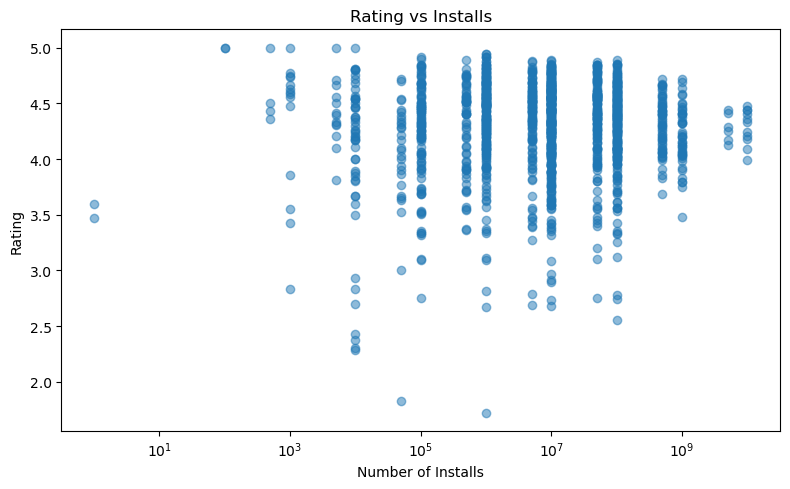

In [63]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Installs"],df["Rating"], alpha=0.5)
plt.xscale("log")
plt.title("Rating vs Installs")
plt.xlabel("Number of Installs")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

In [64]:
# Category vs Installs

In [65]:
category_installs = (df.groupby("Category")["Installs"].mean().sort_values(ascending=False))
print(category_installs)

Category
COMMUNICATION          1.346628e+09
SOCIAL                 5.585000e+08
VIDEO_PLAYERS          5.438415e+08
GAME_MUSIC             3.666667e+08
MUSIC_AND_AUDIO        3.329750e+08
PRODUCTIVITY           3.321442e+08
GAME_ACTION            3.270000e+08
TRAVEL_AND_LOCAL       2.598294e+08
TOOLS                  2.567067e+08
PHOTOGRAPHY            2.542889e+08
GAME_ARCADE            2.417500e+08
GAME_CASUAL            1.750321e+08
SHOPPING               1.313059e+08
GAME_RACING            1.261200e+08
ENTERTAINMENT          1.201024e+08
GAME_STRATEGY          1.083200e+08
COMICS                 1.000000e+08
GAME_SPORTS            1.000000e+08
GAME_PUZZLE            9.922174e+07
WEATHER                9.275333e+07
PERSONALIZATION        9.141643e+07
NEWS_AND_MAGAZINES     8.629032e+07
DATING                 6.713333e+07
MAPS_AND_NAVIGATION    6.541567e+07
GAME_ADVENTURE         5.250000e+07
GAME_BOARD             5.157857e+07
FINANCE                4.750555e+07
GAME_TRIVIA        

In [66]:
# Average Installs by Category

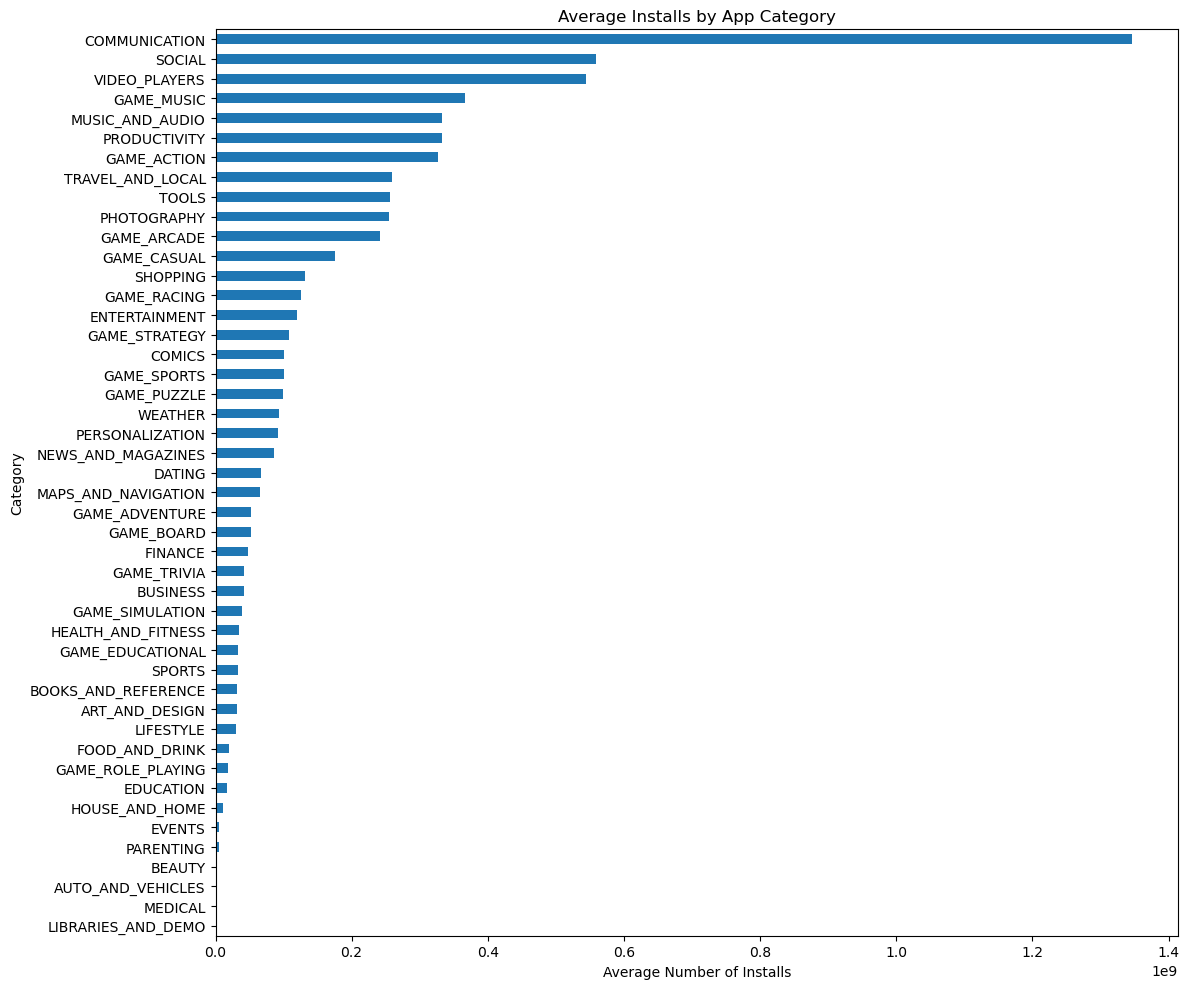

In [67]:
category_installs = (df.groupby("Category")["Installs"].mean().sort_values(ascending=True))
plt.figure(figsize=(12, 10))
category_installs.plot(kind="barh")
plt.title("Average Installs by App Category")
plt.xlabel("Average Number of Installs")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

CATEGORY - LEVEL ANALYSIS

In [68]:
#Average Rating by Category

In [69]:
category_rating = (df.groupby("Category")["Rating"].mean().sort_values(ascending=False))
print(category_rating)

Category
PARENTING              4.571401
HEALTH_AND_FITNESS     4.568991
GAME_PUZZLE            4.455962
FINANCE                4.425829
PRODUCTIVITY           4.422740
EDUCATION              4.416724
GAME_ROLE_PLAYING      4.414216
MEDICAL                4.402007
GAME_SPORTS            4.390709
TRAVEL_AND_LOCAL       4.387775
NEWS_AND_MAGAZINES     4.385705
BOOKS_AND_REFERENCE    4.380075
MUSIC_AND_AUDIO        4.375904
GAME_ADVENTURE         4.360396
WEATHER                4.349089
GAME_TRIVIA            4.333378
BUSINESS               4.329557
ART_AND_DESIGN         4.320401
COMICS                 4.320283
FOOD_AND_DRINK         4.316263
PHOTOGRAPHY            4.315168
LIFESTYLE              4.296033
GAME_MUSIC             4.294372
PERSONALIZATION        4.287483
EVENTS                 4.282829
GAME_RACING            4.272648
TOOLS                  4.271693
GAME_CASUAL            4.267155
GAME_STRATEGY          4.263046
GAME_BOARD             4.234516
MAPS_AND_NAVIGATION    4.210762

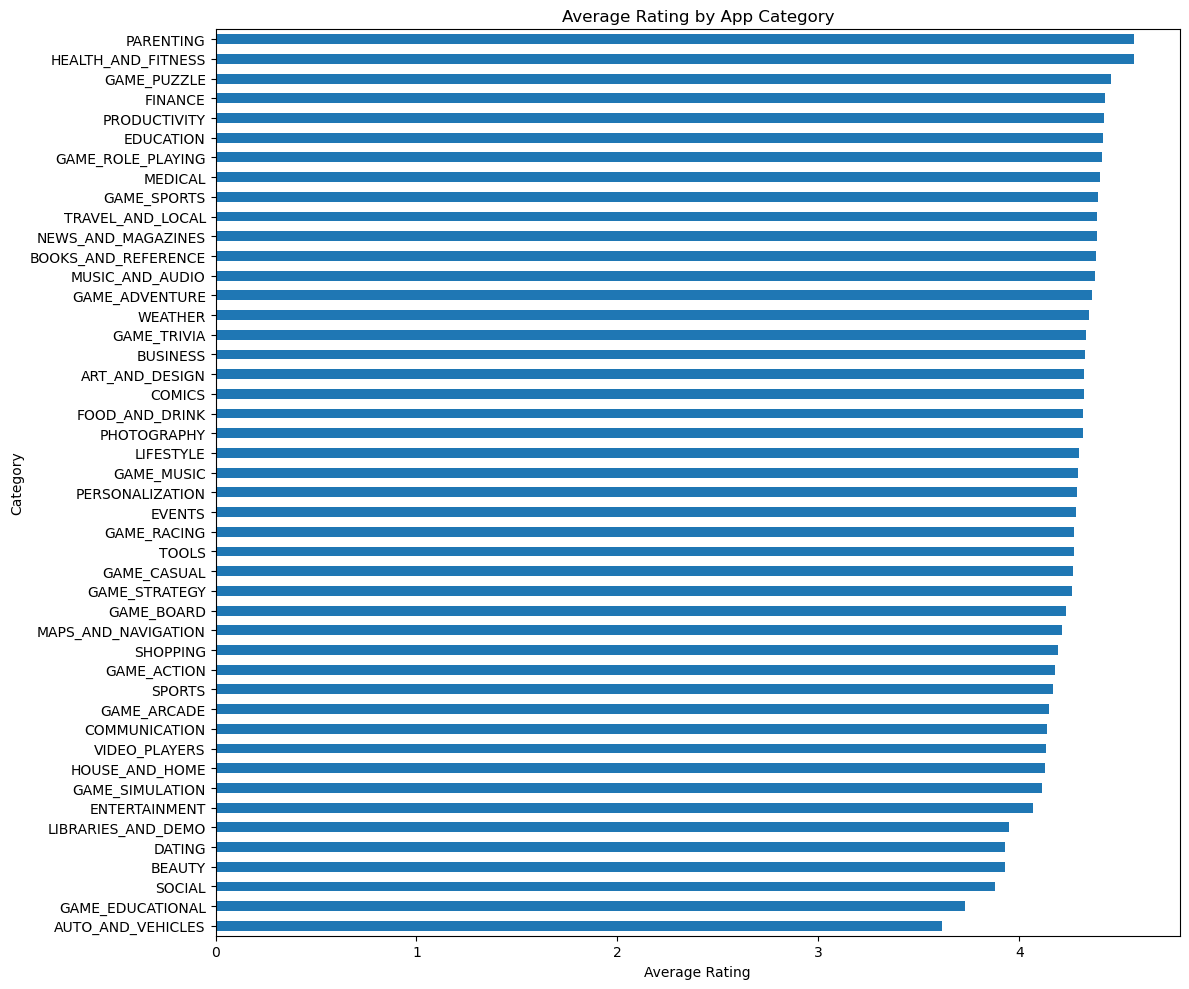

In [72]:
category_rating = (df.groupby("Category")["Rating"] .mean().sort_values(ascending=True))
plt.figure(figsize=(12, 10))
category_rating.plot(kind="barh")
plt.title("Average Rating by App Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [73]:
# Category vs Reviews - Average Reviews by Category

In [74]:
category_reviews = (df.groupby("Category")["Reviews"].mean().sort_values(ascending=False))
print(category_reviews)

Category
COMMUNICATION          1.778740e+07
SOCIAL                 1.257022e+07
GAME_ACTION            6.725147e+06
GAME_STRATEGY          5.806049e+06
VIDEO_PLAYERS          5.608484e+06
GAME_CASUAL            5.458681e+06
GAME_ARCADE            5.125782e+06
SHOPPING               5.124404e+06
COMICS                 4.585897e+06
MUSIC_AND_AUDIO        3.349350e+06
GAME_MUSIC             2.738447e+06
GAME_RACING            2.705635e+06
PHOTOGRAPHY            2.606070e+06
GAME_SPORTS            2.581999e+06
GAME_TRIVIA            2.279573e+06
DATING                 1.915676e+06
FOOD_AND_DRINK         1.863496e+06
GAME_PUZZLE            1.786013e+06
ENTERTAINMENT          1.706635e+06
TRAVEL_AND_LOCAL       1.634013e+06
GAME_BOARD             1.517885e+06
MAPS_AND_NAVIGATION    1.476001e+06
FINANCE                1.277286e+06
NEWS_AND_MAGAZINES     1.194298e+06
EDUCATION              1.070596e+06
ART_AND_DESIGN         9.969092e+05
PRODUCTIVITY           9.491509e+05
TOOLS              

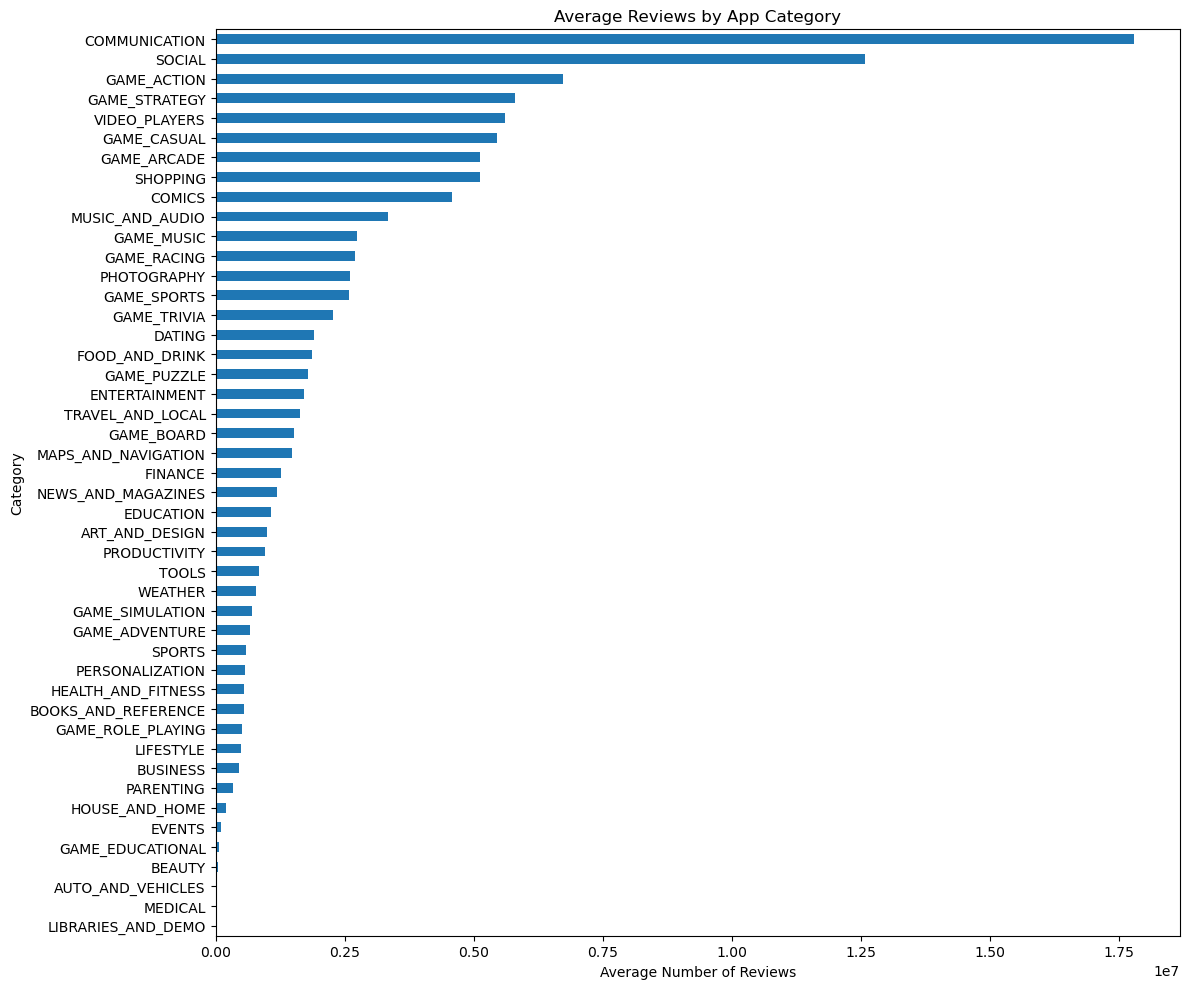

In [75]:
category_reviews = (df.groupby("Category")["Reviews"].mean().sort_values(ascending=True))
plt.figure(figsize=(12, 10))
category_reviews.plot(kind="barh")
plt.title("Average Reviews by App Category")
plt.xlabel("Average Number of Reviews")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

APP - LEVEL ANALYSIS

In [76]:
# Top 10 Apps by Installs

In [77]:
top_apps = (df.groupby("App")["Installs"].max().sort_values(ascending=False).head(10))
print(top_apps)

App
Google Maps           1.000000e+10
YouTube               1.000000e+10
Google Meet           1.000000e+10
Google Messages       1.000000e+10
Google Drive          1.000000e+10
Google Calendar       1.000000e+10
Google Photos         1.000000e+10
WhatsApp Messenger    1.000000e+10
Facebook              1.000000e+10
Google TV             1.000000e+10
Name: Installs, dtype: float64


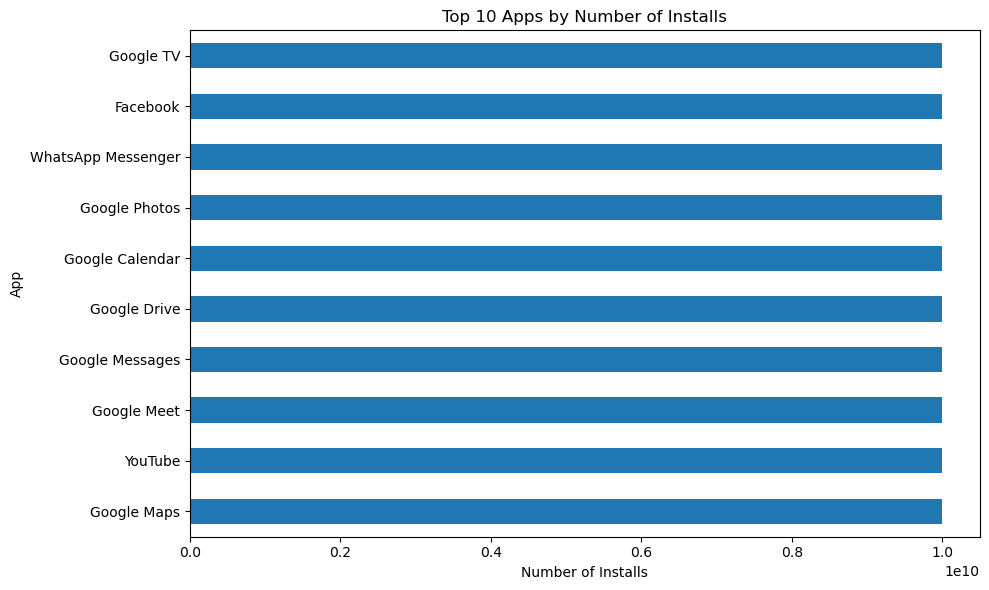

In [78]:
top_apps = (df.groupby("App")["Installs"].max().sort_values(ascending=False).head(10).sort_values(ascending=True))
plt.figure(figsize=(10, 6))
top_apps.plot(kind="barh")
plt.title("Top 10 Apps by Number of Installs")
plt.xlabel("Number of Installs")
plt.ylabel("App")
plt.tight_layout()
plt.show()

In [79]:
# Top 10 Apps by Reviews

In [80]:
top_reviewed_apps = (df.groupby("App")["Reviews"].max() .sort_values(ascending=False).head(10).sort_values(ascending=True))
print(top_reviewed_apps)

App
Google Messages                  46151444.0
Duolingo: Language Lessons       49154848.0
Google Photos                    53899661.0
Clash of Clans                   61366867.0
Flipkart Online Shopping App     76032396.0
Messenger                       113839417.0
Instagram                       169081566.0
YouTube                         171611200.0
Facebook                        185501282.0
WhatsApp Messenger              242656740.0
Name: Reviews, dtype: float64


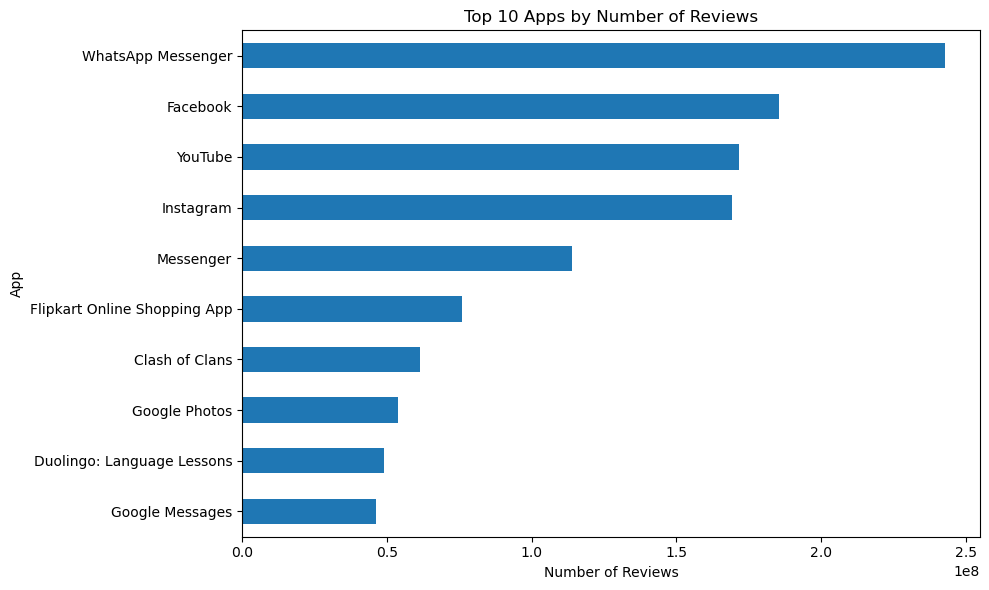

In [81]:
top_reviewed_apps = ( df.groupby("App")["Reviews"].max().sort_values(ascending=False).head(10).sort_values(ascending=True))
plt.figure(figsize=(10, 6))
top_reviewed_apps.plot(kind="barh")
plt.title("Top 10 Apps by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("App")
plt.tight_layout()
plt.show()

In [82]:
# Free vs Paid Apps: Rating

In [83]:
type_rating = (df.groupby("Type")["Rating"].mean().sort_values(ascending=False))
print(type_rating)

Type
Paid    4.456440
Free    4.291129
Name: Rating, dtype: float64


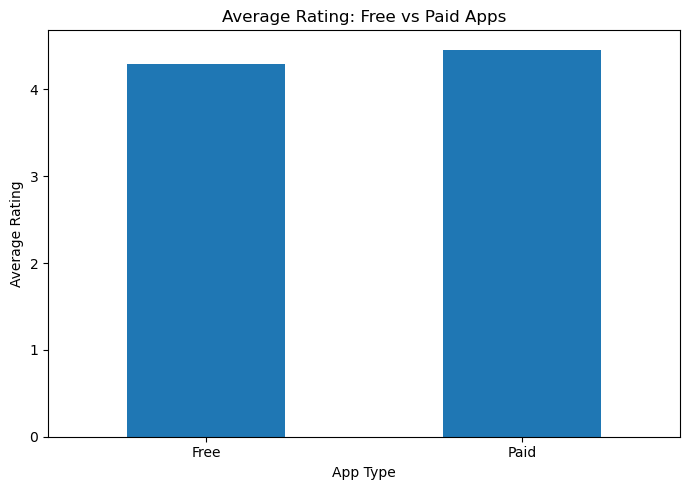

In [84]:
import matplotlib.pyplot as plt

type_rating = (df.groupby("Type")["Rating"].mean().sort_values(ascending=True))
plt.figure(figsize=(7, 5))
type_rating.plot(kind="bar")
plt.title("Average Rating: Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

KEY EDA FINDINGS

• Free apps dominate the dataset, accounting for approximately 98.2% of all apps.

• Communication is the strongest category in terms of both average installs (~1.44B) and average reviews (~19M).

• Installs and reviews show a moderate positive correlation (0.61), indicating that higher reach generally leads to greater
    user engagement.

• App ratings show almost no linear relationship with either installs or reviews, suggesting that popularity does not 
    necessarily translate into higher user satisfaction.

• Parenting and Health & Fitness have the highest average ratings (~4.54), while WhatsApp Messenger leads in total reviews
    (~242.6M).

SQL ANALYSIS

In [86]:
!pip install mysql-connector-python

In [87]:
import mysql.connector

In [88]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Admin@123",
    database="google_play_analysis"
)

print("MySQL connected successfully!")

MySQL connected successfully!


In [89]:
df_sql = pd.read_csv("googleplaystore_cleaned.csv")

In [90]:
print(df_sql.shape)
print(df_sql.columns.tolist())

(1550, 13)
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [97]:
print("df_sql shape:", df_sql.shape)
print("Columns:", df_sql.columns.tolist())
print("Columns being inserted:", df_sql_insert.columns.tolist())

df_sql shape: (1550, 13)
Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
Columns being inserted: ['App', 'Category', 'Rating', 'Reviews', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver']


In [99]:
cursor.execute("SELECT COUNT(*) FROM google_play_apps")
print("Current rows in MySQL:", cursor.fetchone()[0])

Current rows in MySQL: 1550


In [100]:
cursor.execute("TRUNCATE TABLE google_play_apps")
connection.commit()
print("Old MySQL data cleared.")

Old MySQL data cleared.


In [101]:
cursor.execute("SELECT COUNT(*) FROM google_play_apps")
print("Rows in MySQL:", cursor.fetchone()[0])

Rows in MySQL: 0


In [104]:
# Create a fresh copy for MySQL
df_sql_insert = df_sql[["App","Category","Rating","Reviews","Installs","Type","Price","Content Rating","Genres","Last Updated",
                        "Current Ver"]].copy()
data = []
for row in df_sql_insert.itertuples(index=False, name=None):
    cleaned_row = tuple(
        None if pd.isna(value) else value
        for value in row
    )
    data.append(cleaned_row)
print("Rows prepared:", len(data))

Rows prepared: 1550


In [106]:
cursor = connection.cursor()
insert_query = """INSERT INTO google_play_apps(App,Category,Rating,Reviews,Installs,Type,Price,`Content Rating`,Genres,
    `Last Updated`,`Current Ver`)VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)"""
cursor.executemany(insert_query, data)
connection.commit()
print("Data inserted successfully!")
print("Rows inserted:", cursor.rowcount)

Data inserted successfully!
Rows inserted: 1550


In [107]:
cursor.execute("SELECT COUNT(*) FROM google_play_apps")
print("Total rows in MySQL:", cursor.fetchone()[0])

Total rows in MySQL: 1550


In [108]:
cursor.execute("""SELECT App, Type, Price FROM google_play_apps WHERE Type = 'Paid' ORDER BY Price DESC""")
for row in cursor.fetchall():
    print(row)

('Live Home 3D Pro: House Design', 'Paid', Decimal('10000.00'))
('OsmAnd+ — Maps & GPS Offline', 'Paid', Decimal('5000.00'))
('Meme Generator PRO', 'Paid', Decimal('3750.00'))
('Nova Launcher Lifetime Prime', 'Paid', Decimal('3250.00'))
('Weather 14 Days - Meteored Pro', 'Paid', Decimal('2499.00'))
('German Dictionary Pro Offline', 'Paid', Decimal('1600.00'))
('City Maps 2Go Pro Offline Maps', 'Paid', Decimal('1350.00'))
('AlpineQuest Off-Road Explorer', 'Paid', Decimal('1349.99'))
('Moon+ Reader Pro', 'Paid', Decimal('1300.00'))
('ReadEra Premium – ebook reader', 'Paid', Decimal('1190.00'))
('Hanping Cantonese Dictionary', 'Paid', Decimal('1050.00'))
('Horoscope+: Ad-Free Astrology', 'Paid', Decimal('990.00'))
('Dictionary Pro', 'Paid', Decimal('990.00'))
('Dictionary - M-W Premium', 'Paid', Decimal('700.00'))
('Driving Theory Test 4 in 1 Kit', 'Paid', Decimal('700.00'))
('MemeNow Pro - Meme Generator &', 'Paid', Decimal('520.00'))
('Video Player - OPlayer', 'Paid', Decimal('410.00'))

In [109]:
cursor.execute("SELECT COUNT(*) FROM google_play_apps")
print("Total rows in MySQL:", cursor.fetchone()[0])

Total rows in MySQL: 1550


In [110]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(1550, 13)
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
App                  0
Category             0
Rating             110
Reviews            110
Size                 0
Installs             0
Type                 0
Price                3
Content Rating       0
Genres               0
Last Updated       162
Current Ver          0
Android Ver       1550
dtype: int64


In [112]:
df = df.drop(columns=["Android Ver"])

In [113]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

In [114]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
df["Reviews"] = df["Reviews"].fillna(df["Reviews"].median())
df["Reviews"] = df["Reviews"].round().astype("int64")

In [115]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")
df["Installs"] = df["Installs"].fillna(df["Installs"].median())
df["Installs"] = df["Installs"].round().astype("int64")

In [116]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [117]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"],errors="coerce")

In [118]:
df = df.drop(columns=["Size"])

In [119]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Shape: (1550, 11)

Columns:
['App', 'Category', 'Rating', 'Reviews', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver']

Missing values:
App                 0
Category            0
Rating              0
Reviews             0
Installs            0
Type                0
Price               3
Content Rating      0
Genres              0
Last Updated      162
Current Ver         0
dtype: int64

Duplicates: 0


In [6]:
df.to_csv("googleplaystore_cleaned.csv", index=False)
print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [7]:
print(df.shape)

(1550, 13)


In [124]:
print(pd.read_csv("googleplaystore_cleaned.csv").shape)

(1550, 11)
